<a href="https://colab.research.google.com/github/rushikesh-D69/water/blob/main/habitability_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive AI-Driven Telescope Target Prioritization Framework
## Stage 1: Probabilistic Exoplanet Prioritization (v2.1)

**Paper Title:** Adaptive Reinforcement Learning-Based Telescope Target Prioritization for Probabilistic Liquid Water Detection on Exoplanets

---

### What This Notebook Does

This is NOT a habitability classifier. It is a scientific prioritization system that answers:

> Which exoplanets should a telescope observe NEXT to maximize scientific return per observation hour?

---

### Key Design Decisions (v2.1)

| Decision | Old (v1) | New (v2.1) | Reason |
|----------|----------|------------|--------|
| Task | Binary classification | Continuous regression / ranking | Prioritization is not binary |
| Data leakage | HZ/ESI used as features | HZ/ESI used only for label | Prevents circular learning |
| Target | habitable = 0/1 | priority_score in [0,1] | Ranking requires ordinal target |
| Observation | Not modelled | SNR proxy, detectability, distance | Real telescope scheduling |
| Uncertainty | None | Ensemble variance per planet | Research-grade uncertainty quantification |
| Scientific gain | None | uncertainty * detectability | Information-theoretic scheduling |
| Metrics | ROC-AUC, F1 | NDCG, MAP, Spearman rho, Kendall tau | Ranking-appropriate evaluation |
| Scoring | Strict multiplicative | Soft geometric + diversity + detectability blend | Avoids near-zero collapse |
| Distribution | Skewed | Quantile normalized to uniform [0,1] | Better for ranking / RL |

---

### Priority Score Formula (v2.1)

**Step 1 -- Soft geometric mean (eps = 0.1 avoids near-zero collapse):**

$$P_{\text{astro}} = (H + \varepsilon)^{0.5} \cdot (R + \varepsilon)^{0.3} \cdot (E + \varepsilon)^{0.2}, \quad \varepsilon = 0.1$$

**Step 2 -- Tiny diversity nudge (prevents ranking collapse into one narrow band):**

$$P_{\text{astro}} \mathrel{+}= 0.02 \cdot f_{\text{ecc}} + 0.02 \cdot f_{\text{met}} + 0.01 \cdot f_{\text{age}}$$

**Step 3 -- Detectability blend (astrophysics dominates, telescope gently influences):**

$$P_{\text{final}} = 0.85 \cdot P_{\text{astro}} + 0.15 \cdot D$$

**Step 4 -- Quantile normalize to uniform [0,1]:**

$$\text{priority\_score} = \text{QuantileTransformer}(\text{uniform}).\text{fit\_transform}(P_{\text{final}})$$

---

### Scientific Gain (observation value metric):

$$\text{ScientificGain}_i = \sigma_i \times \text{Detectability}_i$$

### Ranking Metrics:

$$\text{NDCG@K} = \frac{DCG@K}{IDCG@K} = \frac{\sum_{i=1}^{K} \text{score}_i / \log_2(i+1)}{\text{ideal}}$$


---
## 0. Environment Setup

This cell handles both **Google Colab** (clones from GitHub) and **local** environments automatically.

In [1]:
# ==============================================================
# CELL 1 — PULL FROM GITHUB  (run at START of every session)
# ==============================================================
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

GITHUB_USER = 'rushikesh-D69'
REPO_NAME   = 'water'
BRANCH      = 'main'
REPO_URL    = f'https://github.com/{GITHUB_USER}/{REPO_NAME}.git'

if IN_COLAB:
    REPO_PATH = f'/content/{REPO_NAME}'

    if not os.path.exists(REPO_PATH):
        print(f'[Git] Cloning {REPO_URL} ...')
        os.system(f'git clone {REPO_URL} {REPO_PATH}')
    else:
        print('[Git] Repo exists. Pulling latest ...')
        os.system(f'git -C {REPO_PATH} pull origin {BRANCH}')

    os.chdir(REPO_PATH)
    sys.path.insert(0, REPO_PATH)

    print('[Colab] Installing dependencies ...')
    os.system(
        'pip install -q xgboost lightgbm shap scipy '
        'scikit-learn matplotlib seaborn requests joblib'
    )
    print('[Colab] Ready.')

else:
    ROOT = os.path.abspath('.')
    if ROOT not in sys.path:
        sys.path.insert(0, ROOT)
    print(f'[Local] Project root: {ROOT}')


[Git] Cloning https://github.com/rushikesh-D69/water.git ...
[Colab] Installing dependencies ...
[Colab] Ready.


---
## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import joblib
from scipy.stats import spearmanr, kendalltau
from IPython.display import Image, display

from src.data_acquisition import (
    fetch_nasa_exoplanets, run_pipeline,
    ML_FEATURES, TARGET, DATA_DIR, PLOTS_DIR
)
from src.ml_pipeline import (
    load_data, run_ml_pipeline,
    compute_ranking_metrics, ndcg_at_k, map_at_k, regret_at_k
)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.dpi'] = 100
print('All imports OK')

All imports OK


---
## 2. Data Acquisition -- NASA Exoplanet Archive

Fetches from `pscomppars` (Planetary Systems Composite Parameters) via TAP API.
Cached locally after first download.

In [3]:
# Run the full data pipeline
# force_refresh=True to re-download from NASA
df_ml, feature_names = run_pipeline(force_refresh=False)

print(f'Dataset: {df_ml.shape}')
print(f'Features: {len(feature_names)}')
print(f'Target: {TARGET} (continuous [0,1])')

  Stage 1 -- Data Acquisition & Feature Engineering v2.0
[Data] Fetching data from NASA Exoplanet Archive TAP ...
[Data] Downloaded 6,284 records in 2.2s -> /content/water/data/exoplanets_raw.csv

[Info]  Raw dataset shape: (6284, 27)
[Impute] Filled 24 missing planet masses from radius.
[Impute] Filled 43 missing planet radii from mass.
[Derive] Computed 1,078 missing equilibrium temperatures.
[Derive] Computed 85 missing planet densities.
[Obs]   Observation feasibility features computed.
[Encode] Spectral class one-hot encoded.
[Label] CHZ/OHZ calculation complete.
[Label] Priority score v2.1 computed (quantile-normalised).
        3,141 planets in top 50% | mean=0.5000 | std=0.2887
[Clean] ML-ready: 5,522 planets | 31 features | target: priority_score

[Save]  Processed dataset -> /content/water/data/exoplanets_processed.csv

[Plots] Generating exploratory visualisations ...
[Plot]  Saved -> /content/water/plots/priority_score_distribution.png
[Plot]  Saved -> /content/water/plots/

In [4]:
# Preview raw data
preview_cols = ['pl_name', 'hostname', 'pl_rade', 'pl_bmasse', 'pl_eqt',
                'pl_orbsmax', 'st_teff', 'detectability', 'priority_score']
df_ml[preview_cols].head(10)

,pl_name,hostname,pl_rade,pl_bmasse,pl_eqt,pl_orbsmax,st_teff,detectability,priority_score
0,11 Com b,11 Com,12.2000,4914.8985,734.7284,1.1780,4874.0000,0.1181,0.3988
1,11 UMi b,11 UMi,12.3000,4684.8142,819.9469,1.5300,4213.0000,0.0857,0.3568
2,14 And b,14 And,13.1000,1131.1513,832.2926,0.7750,4888.0000,0.1411,0.4623
3,14 Her b,14 Her,12.5000,2828.6728,134.7541,2.8390,5338.0000,0.2508,0.5195
4,16 Cyg B b,16 Cyg B,13.5000,565.7374,209.2463,1.6600,5750.0000,0.2428,0.9840
5,17 Sco b,17 Sco,12.9000,1373.0187,775.2080,1.4500,4157.0000,0.0860,0.4175
6,18 Del b,18 Del,12.5000,2926.2461,414.0951,2.4760,4980.0000,0.1400,0.4690
7,1RXS J160929.1-210524 b,1RXS J160929.1-210524,18.6470,3000.0000,1700.0000,330.0000,4060.0000,0.0746,0.1679
8,24 Boo b,24 Boo,13.9000,280.6425,1683.8065,0.1940,4816.0000,0.1149,0.1200
9,24 Sex b,24 Sex,13.4000,632.4600,431.1094,1.3330,5098.0000,0.1459,0.4364


In [5]:
# Verify NO data leakage: HZ/ESI must NOT appear in ML features
leakage_cols = ['hz_factor', 'esi', 'hz_rv', 'hz_rg', 'hz_mg', 'hz_em',
                '_hz_factor_diag', '_esi_diag', '_rocky_diag']
leak_found = [c for c in leakage_cols if c in feature_names]

if leak_found:
    print(f'WARNING - Leakage detected: {leak_found}')
else:
    print('No leakage. HZ/ESI correctly excluded from ML features.')
    print(f'\nML feature set ({len(feature_names)} features):')
    for i, f in enumerate(feature_names, 1):
        print(f'  {i:2d}. {f}')

No leakage. HZ/ESI correctly excluded from ML features.

ML feature set (31 features):
   1. pl_rade
   2. pl_bmasse
   3. pl_dens
   4. pl_orbper
   5. pl_orbsmax
   6. pl_orbeccen
   7. pl_orbincl
   8. pl_eqt
   9. pl_insol
  10. st_teff
  11. st_rad
  12. st_mass
  13. st_lum_linear
  14. st_met
  15. st_logg
  16. st_age
  17. sy_dist
  18. sy_vmag
  19. sy_jmag
  20. snr_proxy
  21. distance_penalty
  22. transit_depth_norm
  23. obs_duration_norm
  24. detectability
  25. star_O
  26. star_B
  27. star_A
  28. star_F
  29. star_G
  30. star_K
  31. star_M


---
## 3. Priority Score -- Target Label Analysis (v2.1)

The target is built via **weak supervision** using astrophysical theory.

**Formula breakdown:**

| Component | Formula | Weight | Role |
|-----------|---------|--------|------|
| H (thermal) | Kopparapu HZ factor | 0.5 | Dominant constraint |
| R (rocky) | Density + radius proxy | 0.3 | Physical suitability |
| E (ESI) | Earth Similarity Index | 0.2 | Multi-param similarity |
| f_ecc | 1 - eccentricity | 0.02 | Orbital stability nudge |
| f_met | Gaussian at [Fe/H]=0 | 0.02 | Solar metallicity nudge |
| f_age | Gaussian at 5 Gyr | 0.01 | Mature system nudge |
| D (detectability) | SNR + distance + transit | 15% blend | Telescope feasibility |

**Why soft geometric (not strict multiplicative)?**
- Old: `H^0.5 * R^0.3 * E^0.2` -- if any factor = 0, total score = 0
- New: `(H+0.1)^0.5 * (R+0.1)^0.3 * (E+0.1)^0.2` -- partial credit preserved

**Why quantile normalize?**
- Uniform [0,1] distribution: better gradient signal for ML models
- Smoother uncertainty estimation across score range
- Directly usable as reward signal in Stage 3 RL without rescaling

The label components (H, R, E) are **excluded from ML features** -- no leakage.


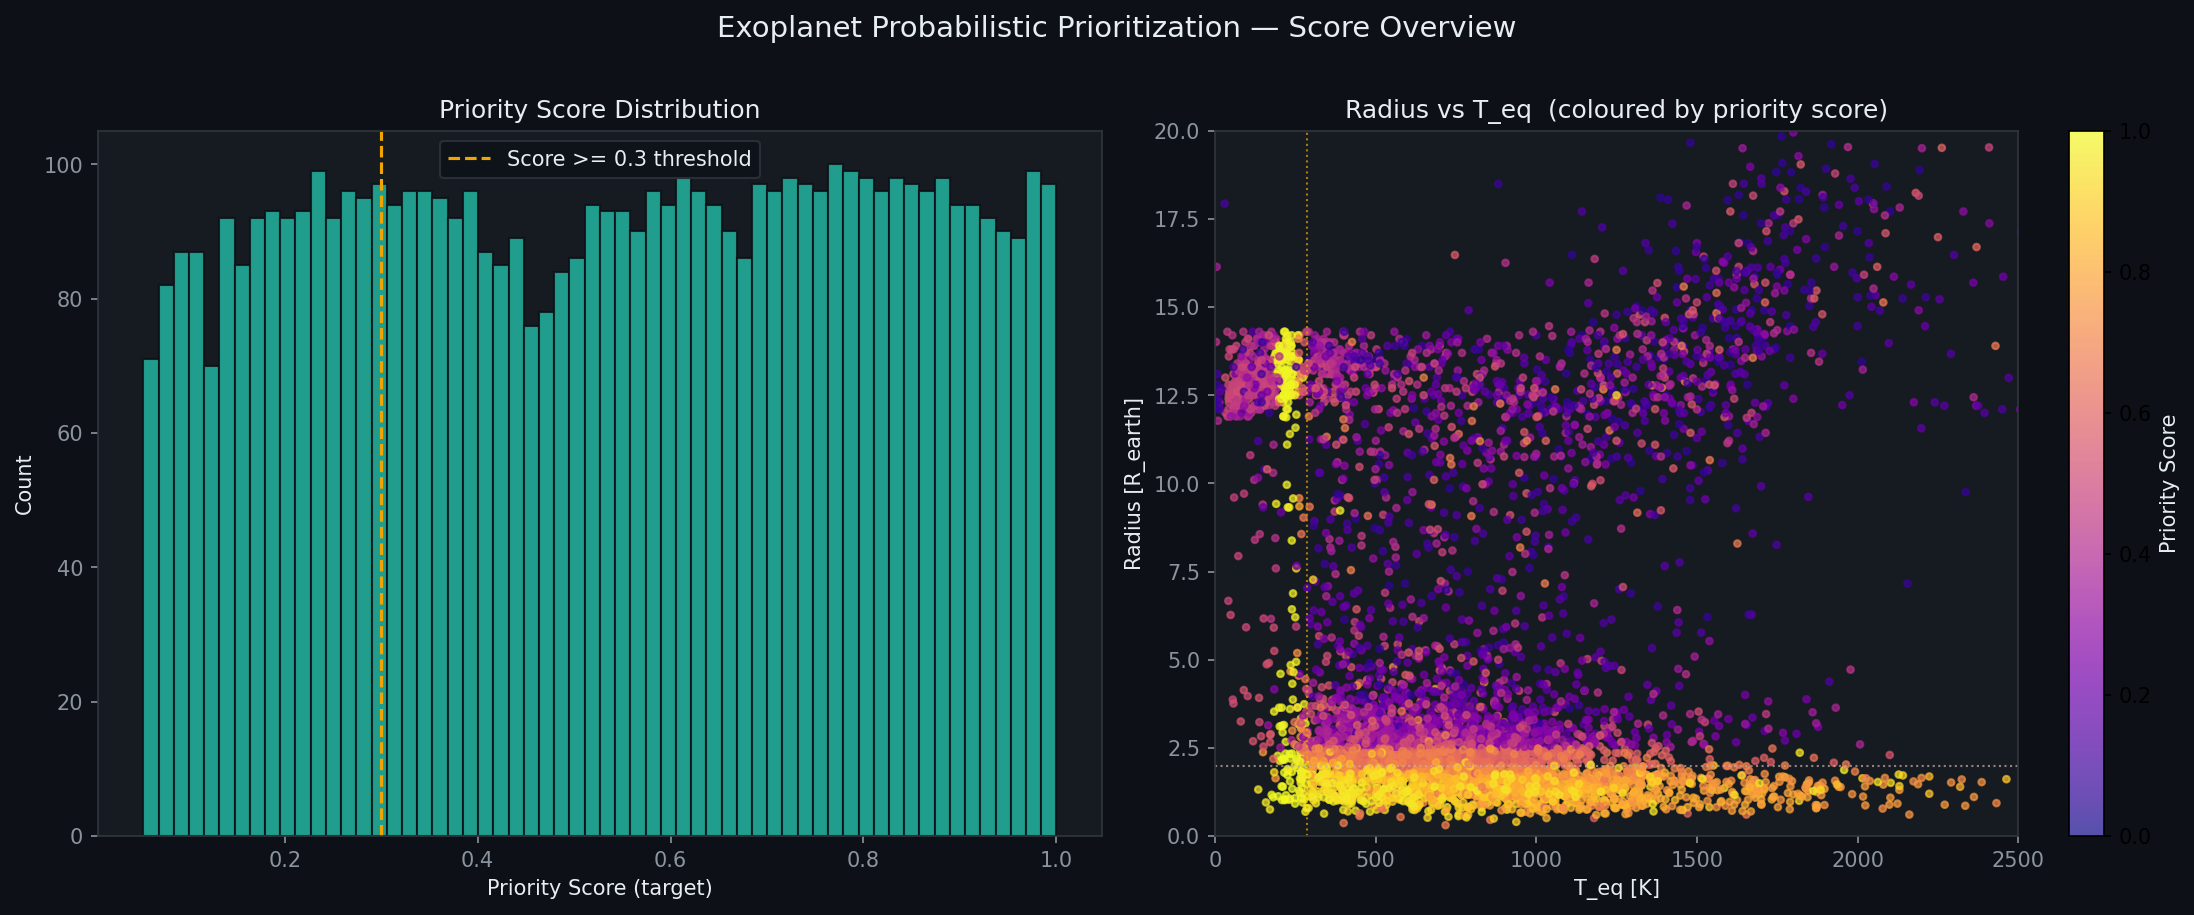

In [6]:
Image(str(PLOTS_DIR / 'priority_score_distribution.png'), width=1000)

In [7]:
ps = df_ml['priority_score']
print('Priority Score Statistics:')
print(f'  Mean:    {ps.mean():.4f}')
print(f'  Std:     {ps.std():.4f}')
print(f'  Max:     {ps.max():.4f}')
print(f'  Median:  {ps.median():.4f}')
print(f'  >= 0.30: {(ps >= 0.30).sum():,} planets ({100*(ps>=0.30).mean():.1f}%)')
print(f'  >= 0.20: {(ps >= 0.20).sum():,} planets ({100*(ps>=0.20).mean():.1f}%)')

Priority Score Statistics:
  Mean:    0.5356
  Std:     0.2717
  Max:     1.0000
  Median:  0.5419
  >= 0.30: 4,136 planets (74.9%)
  >= 0.20: 4,735 planets (85.7%)


In [8]:
# Top 20 planets by raw priority score (ground truth from weak supervision)
top_raw = df_ml.nlargest(20, 'priority_score')[
    ['pl_name', 'hostname', 'priority_score', 'detectability',
     'pl_rade', 'pl_eqt', 'pl_orbsmax', 'st_teff', 'spectral_class']
].reset_index(drop=True)
top_raw.index += 1

print('Top 20 Planets by Priority Score (weak supervision label):')
display(top_raw.style
    .background_gradient(subset=['priority_score', 'detectability'], cmap='YlGn')
    .format({'priority_score': '{:.4f}', 'detectability': '{:.4f}',
             'pl_rade': '{:.2f}', 'pl_eqt': '{:.0f}', 'pl_orbsmax': '{:.3f}'}))

Top 20 Planets by Priority Score (weak supervision label):


,pl_name,hostname,priority_score,detectability,pl_rade,pl_eqt,pl_orbsmax,st_teff,spectral_class
1,LHS 1140 b,LHS 1140,1.0000,0.3560,1.73,226,0.095,3096.000000,M
2,TRAPPIST-1 f,TRAPPIST-1,1.0000,0.2834,1.04,218,0.038,2566.000000,M
3,GJ 251 c,GJ 251,0.9999,0.2837,1.80,216,0.196,3342.000000,M
4,Teegarden's Star c,Teegarden's Star,0.9997,0.2887,1.02,209,0.045,3034.000000,M
5,Kepler-296 f,Kepler-296,0.9993,0.0575,1.80,274,0.255,3740.000000,K
6,K2-288 B b,K2-288 B,0.9992,0.1567,1.90,226,0.164,3341.000000,M
7,GJ 1061 d,GJ 1061,0.9991,0.2892,1.16,221,0.054,2953.000000,M
8,Proxima Cen b,Proxima Cen,0.9986,0.2961,1.02,218,0.048,2900.000000,M
9,GJ 682 b,GJ 682,0.9985,0.2853,1.93,258,0.080,3028.000000,M
10,Wolf 1069 b,Wolf 1069,0.9984,0.2726,1.08,250,0.067,3158.000000,M


---
## 4. Observation Feasibility Analysis

Observation features are **real ML inputs** (not label components).
They model telescope scheduling cost/benefit:

| Feature | Physical Meaning |
|---------|------------------|
| `snr_proxy` | Signal-to-noise proxy for atmospheric spectroscopy |
| `distance_penalty` | Accessibility penalty: exp(-d / 100 pc) |
| `transit_depth_norm` | Normalised transit depth (fraction of starlight blocked) |
| `obs_duration_norm` | Normalised transit duration |
| `detectability` | Composite observability = 0.5*SNR + 0.3*dist_pen + 0.2*depth |

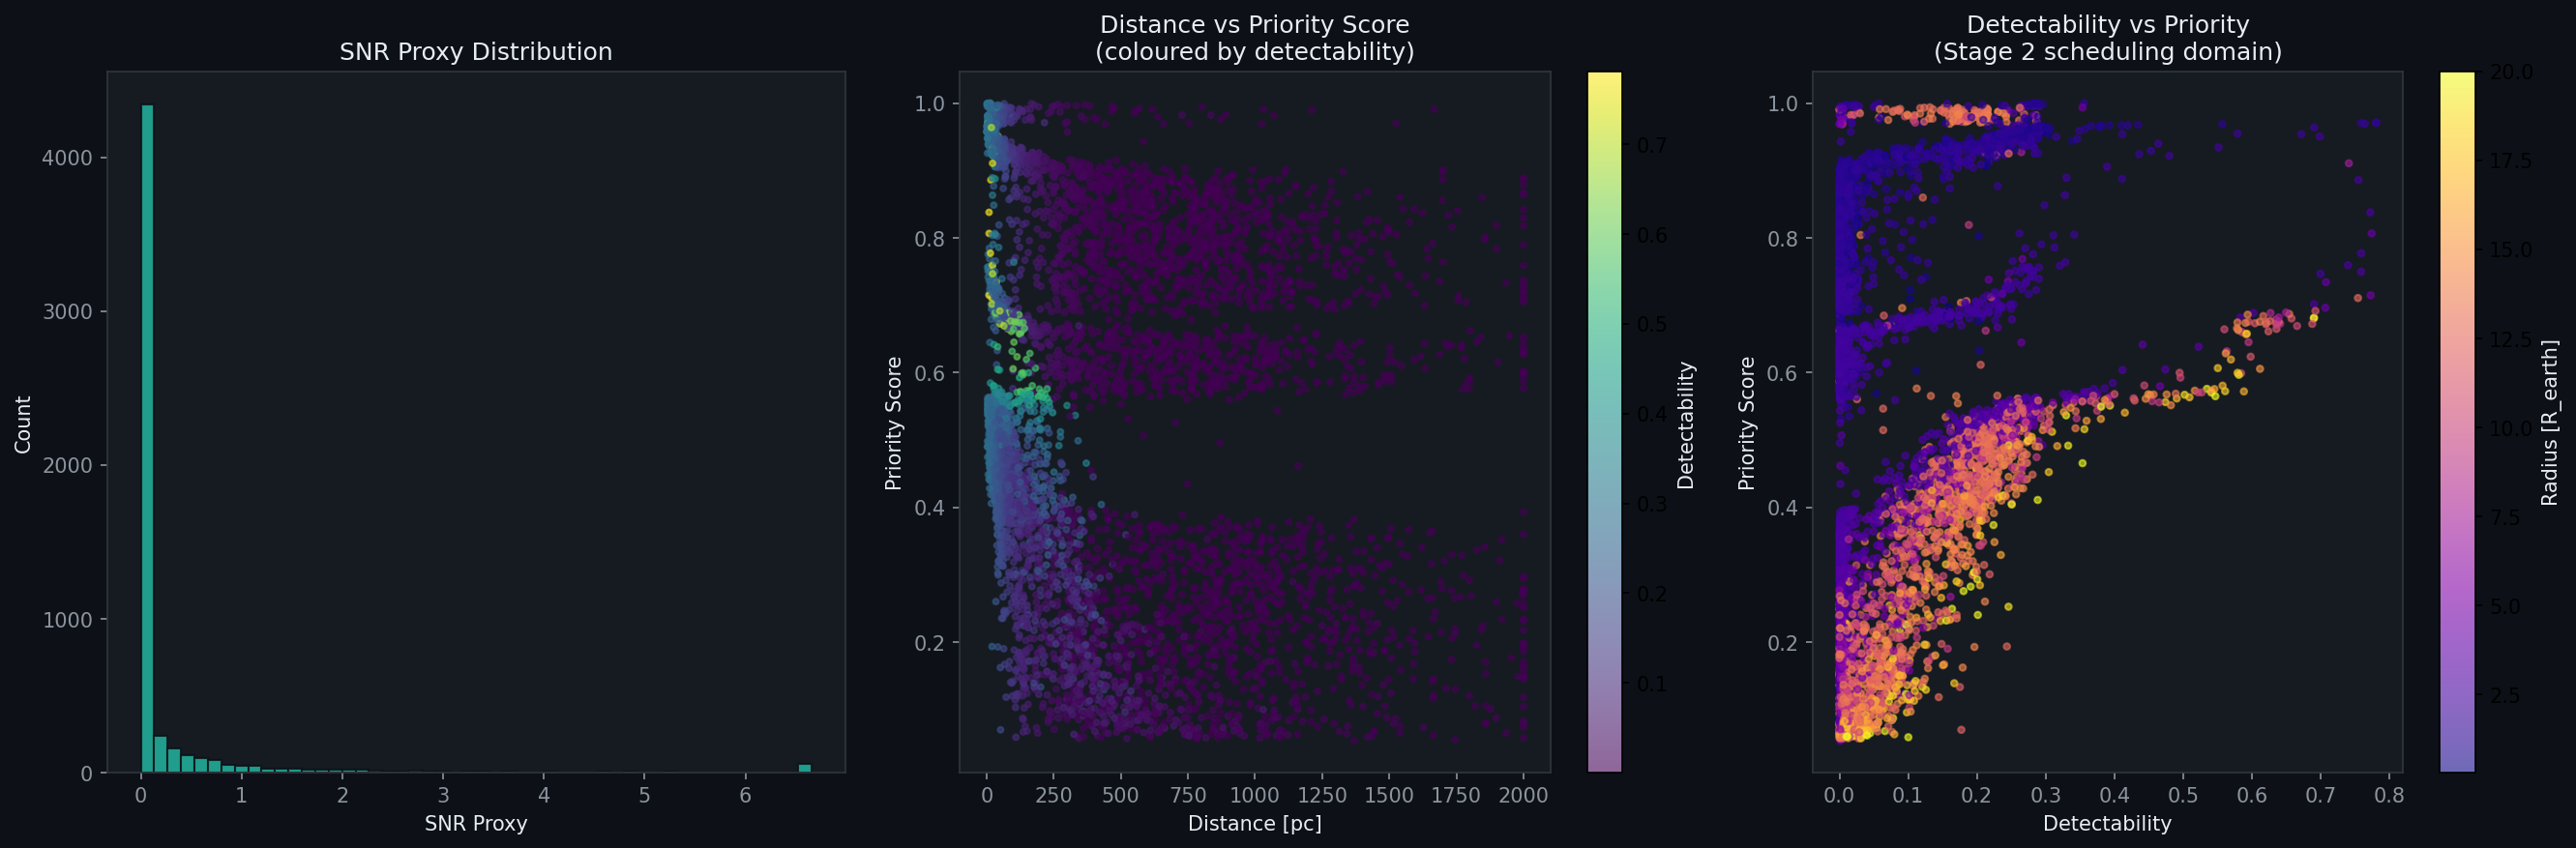

In [9]:
Image(str(PLOTS_DIR / 'observability_analysis.png'), width=1100)

In [10]:
# Planets with best combined priority + detectability
df_ml['obs_utility'] = df_ml['priority_score'] * df_ml['detectability']
top_obs = df_ml.nlargest(15, 'obs_utility')[
    ['pl_name', 'hostname', 'priority_score', 'detectability', 'obs_utility',
     'snr_proxy', 'sy_dist', 'pl_rade', 'st_teff']
].reset_index(drop=True)
top_obs.index += 1

print('Top 15 Planets by Observation Utility (priority * detectability):')
display(top_obs.style
    .background_gradient(subset=['obs_utility', 'priority_score', 'detectability'], cmap='plasma')
    .format({'priority_score': '{:.4f}', 'detectability': '{:.4f}',
             'obs_utility': '{:.4f}', 'snr_proxy': '{:.2f}',
             'sy_dist': '{:.1f}', 'pl_rade': '{:.2f}'}))

Top 15 Planets by Observation Utility (priority * detectability):


,pl_name,hostname,priority_score,detectability,obs_utility,snr_proxy,sy_dist,pl_rade,st_teff
1,HD 219134 c,HD 219134,0.9710,0.7811,0.7585,10.47,6.5,1.51,4699.000000
2,HD 219134 b,HD 219134,0.9709,0.7812,0.7585,8.90,6.5,1.60,4699.000000
3,55 Cnc e,55 Cnc,0.9695,0.7647,0.7413,5.92,12.6,1.88,5172.000000
4,HD 136352 b,HD 136352,0.9707,0.7591,0.7369,7.80,14.7,1.66,5664.000000
5,TOI-2134 c,TOI-2134,0.9107,0.7414,0.6752,26.71,22.6,7.27,4580.000000
6,GJ 143 b,GJ 143,0.8860,0.7553,0.6692,9.28,16.3,2.61,4640.000000
7,pi Men c,HD 39091,0.9638,0.6909,0.6659,5.19,18.3,2.02,5998.000000
8,BD+05 4868 A b,BD+05 4868 A,0.9506,0.6990,0.6645,7.96,43.6,2.36,4596.000000
9,AU Mic c,AU Mic,0.8380,0.7725,0.6473,11.78,9.7,2.79,3540.000000
10,HD 63433 b,HD 63433,0.9540,0.6722,0.6413,5.09,22.4,2.14,5553.000000


---
## 5. Feature Correlation Analysis

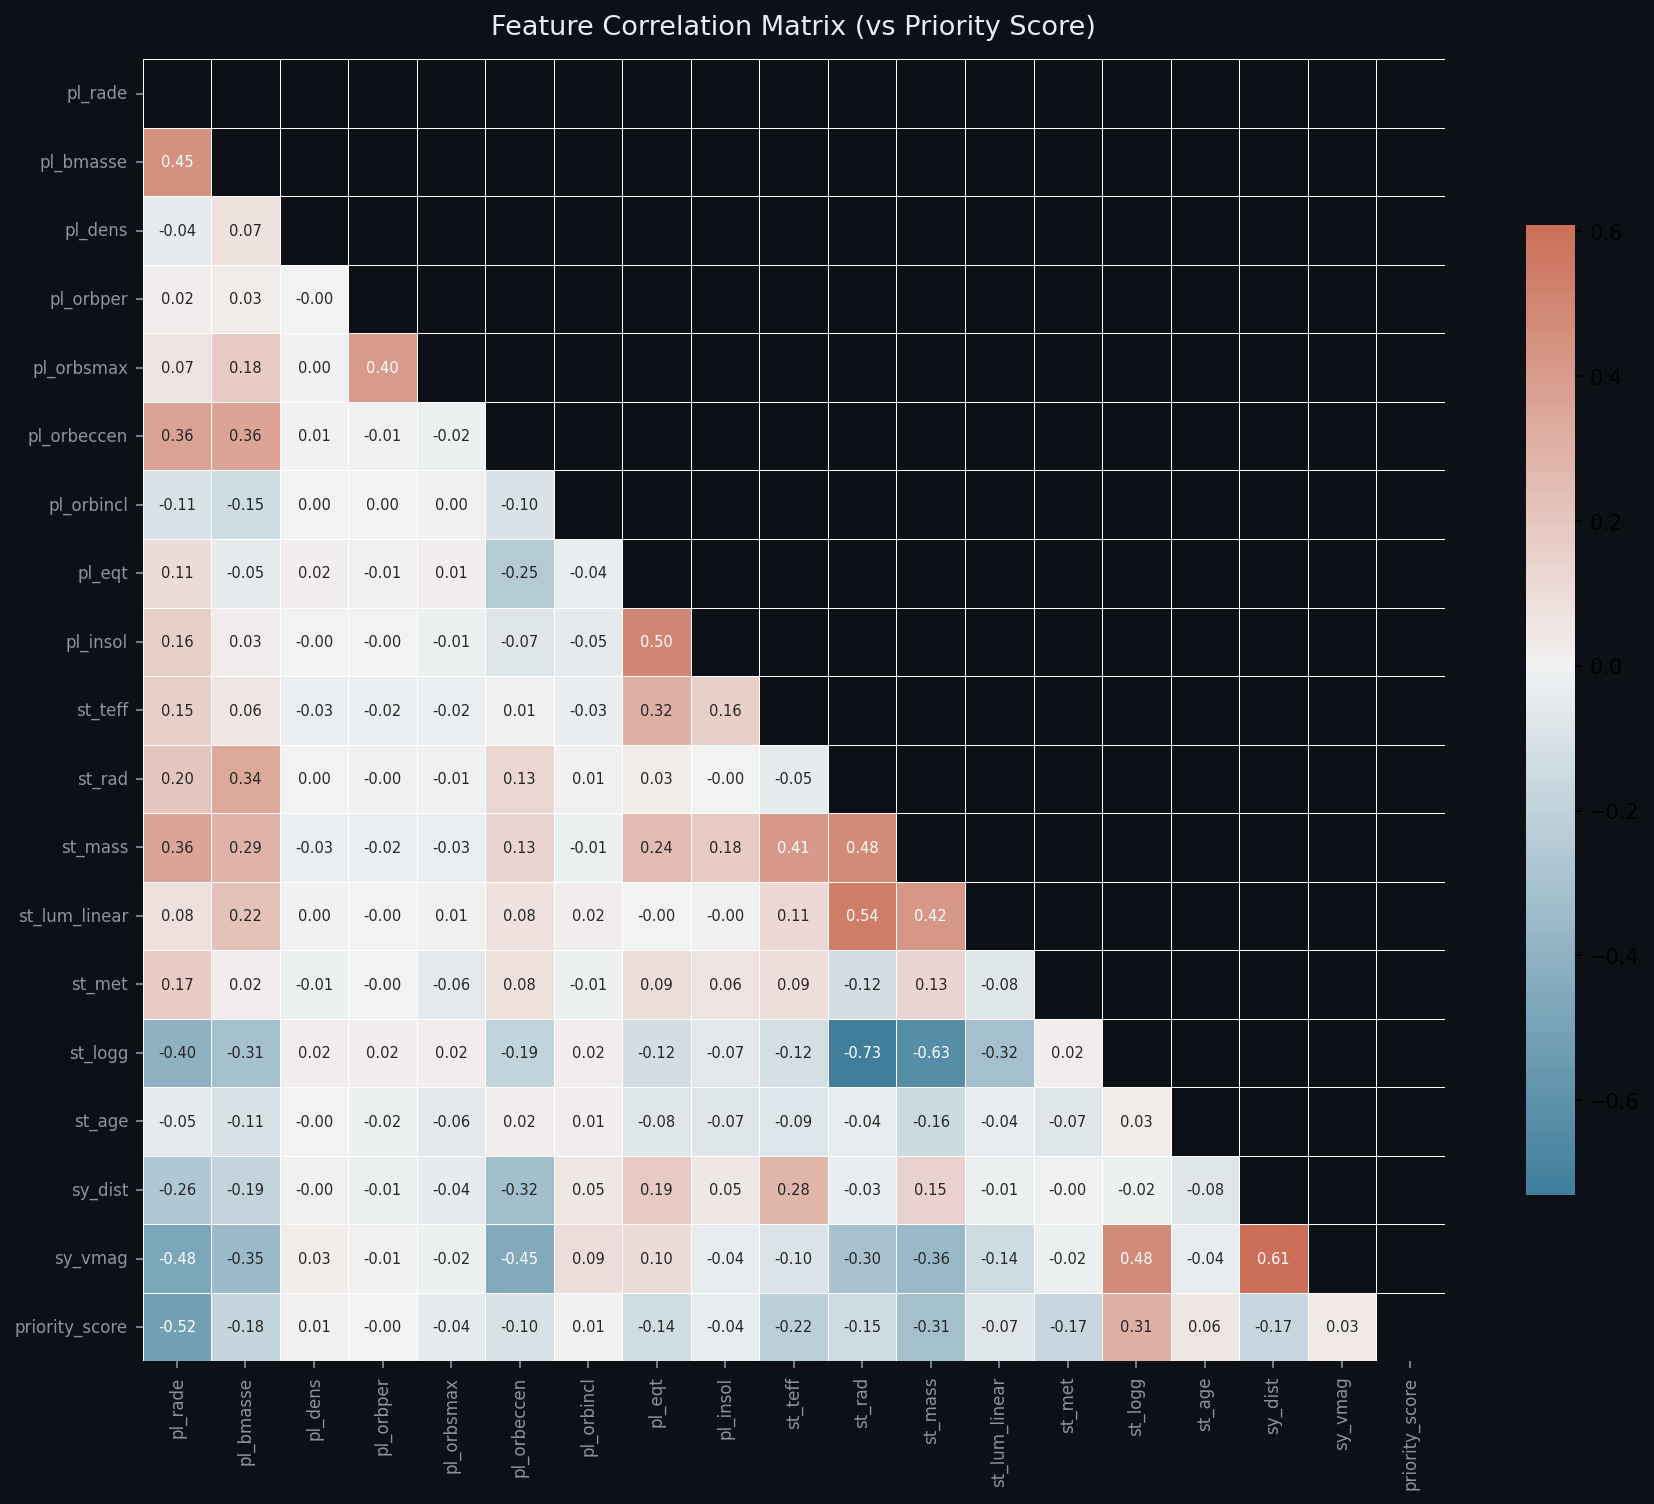

In [11]:
Image(str(PLOTS_DIR / 'feature_correlations.png'), width=900)

In [12]:
key_feats = feature_names + ['priority_score']
key_feats = [f for f in key_feats if f in df_ml.columns]
corr_with_target = df_ml[key_feats].corr()['priority_score'].drop('priority_score')
print('Feature Correlations with Priority Score (sorted by |correlation|):')
print(corr_with_target.abs().sort_values(ascending=False).head(20).round(4).to_string())

Feature Correlations with Priority Score (sorted by |correlation|):
pl_rade              0.5211
st_mass              0.3138
st_logg              0.3069
distance_penalty     0.2520
star_M               0.2288
st_teff              0.2209
pl_bmasse            0.1818
detectability        0.1733
st_met               0.1705
sy_dist              0.1677
transit_depth_norm   0.1613
obs_duration_norm    0.1566
st_rad               0.1545
pl_eqt               0.1371
star_F               0.1370
pl_orbeccen          0.1043
star_K               0.1027
star_G               0.0910
st_lum_linear        0.0745
st_age               0.0590


---
## 6. Machine Learning -- Probabilistic Prioritization Models

We train **regression** models to predict `priority_score` from raw astrophysical parameters.

Evaluation uses **ranking metrics** because the order matters, not the absolute score:
- Spearman rho and Kendall tau: rank correlation
- NDCG@K: quality of top-K recommendations
- MAP@K: precision of top-K selection
- Regret@K: scientific value missed by not selecting the ideal top-K

5-Fold CV is run on Spearman correlation (not R2) to measure ranking generalization.

In [13]:
results, ranking, sim_log = run_ml_pipeline()

  Stage 1 -- Probabilistic Prioritization ML Pipeline v2.0
[Data]  5,522 planets | 31 features
        Priority score  mean=0.5356  std=0.2717  max=1.0000

[Train] Random Forest ...
        NDCG@50:      0.9770
        MAP@50:       1.0000
        Spearman rho: 0.9719
        Kendall tau:  0.8821
        Regret@50:    0.0244
        R2:           0.9428
        RMSE:         0.0659
        CV Spearman:  0.9663 +/- 0.0039

[Train] XGBoost ...
        NDCG@50:      0.9905
        MAP@50:       1.0000
        Spearman rho: 0.9850
        Kendall tau:  0.9300
        Regret@50:    0.0106
        R2:           0.9709
        RMSE:         0.0470
        CV Spearman:  0.9813 +/- 0.0039

[Train] Gradient Boosting ...
        NDCG@50:      0.9754
        MAP@50:       0.9852
        Spearman rho: 0.9836
        Kendall tau:  0.9290
        Regret@50:    0.0296
        R2:           0.9678
        RMSE:         0.0495
        CV Spearman:  0.9814 +/- 0.0039

[Train] LightGBM ...
        NDCG@50

---
## 7. Ranking Performance Analysis

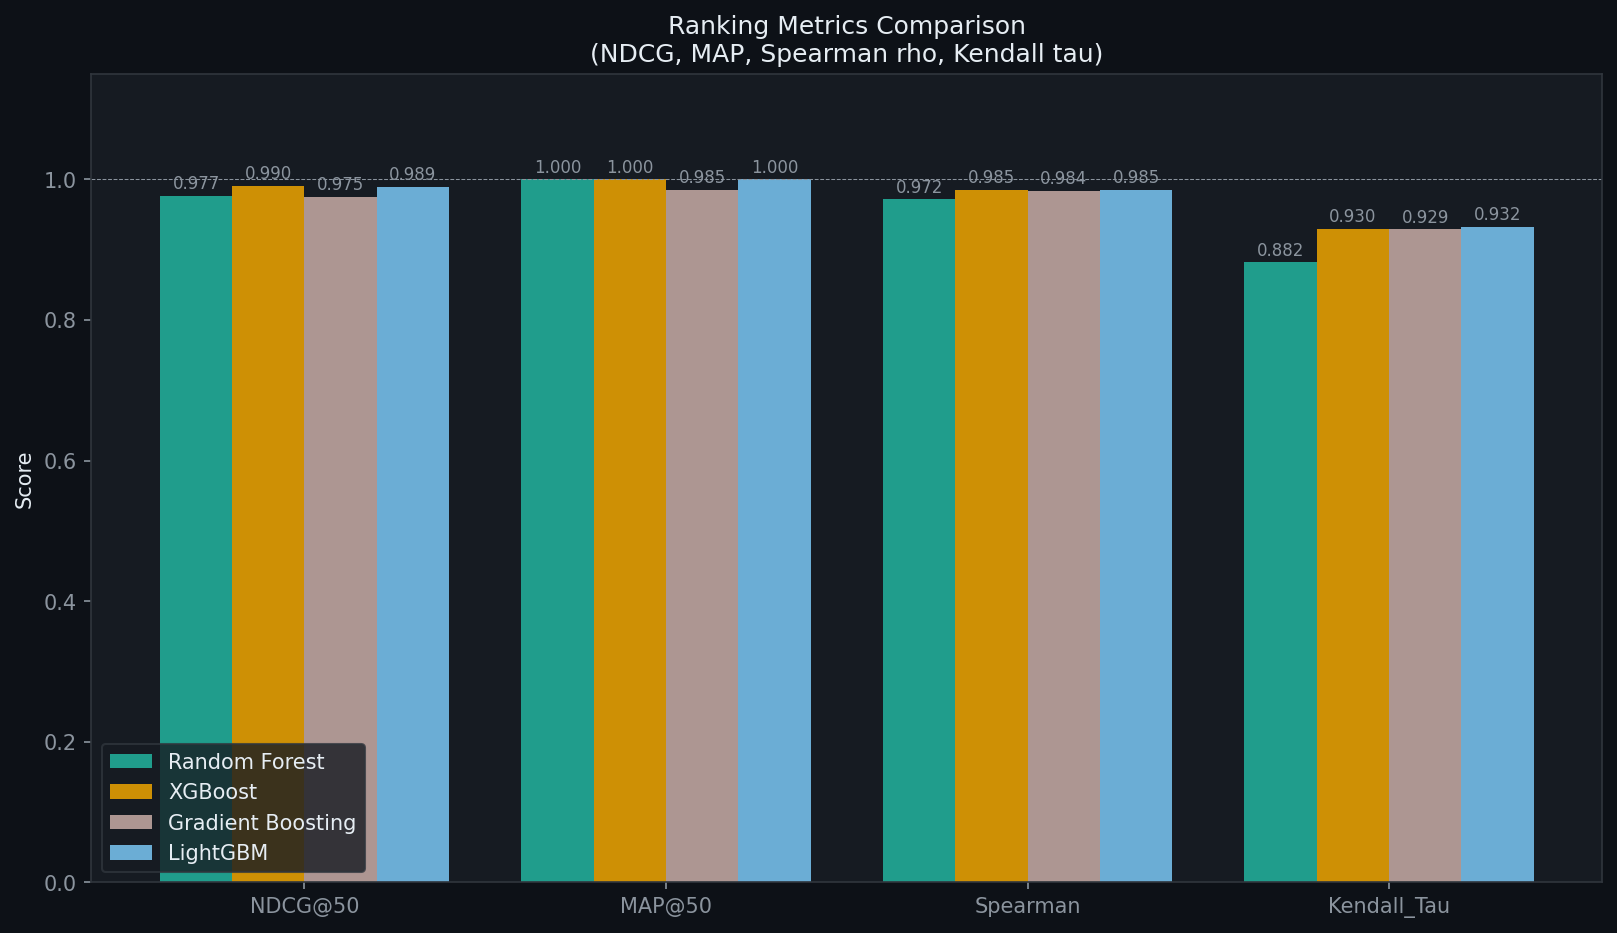

In [14]:
Image(str(PLOTS_DIR / 'ranking_metrics.png'), width=900)

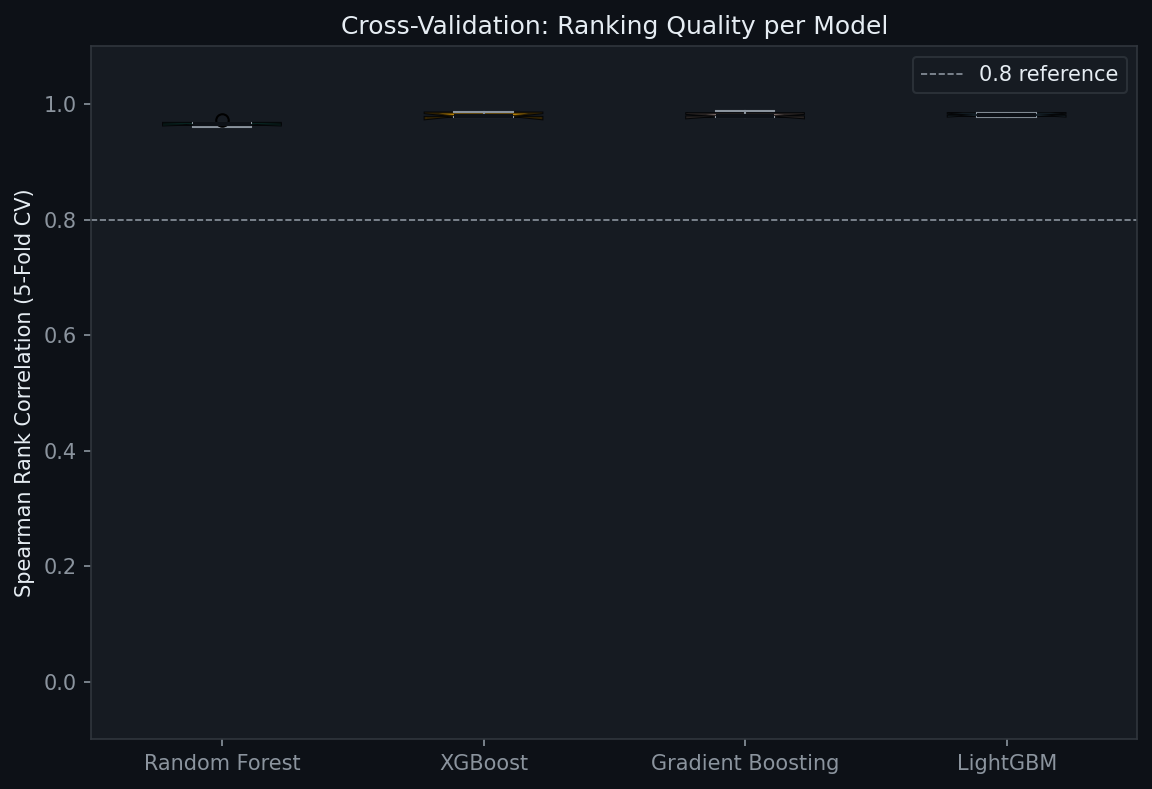

In [15]:
Image(str(PLOTS_DIR / 'cv_spearman.png'), width=750)

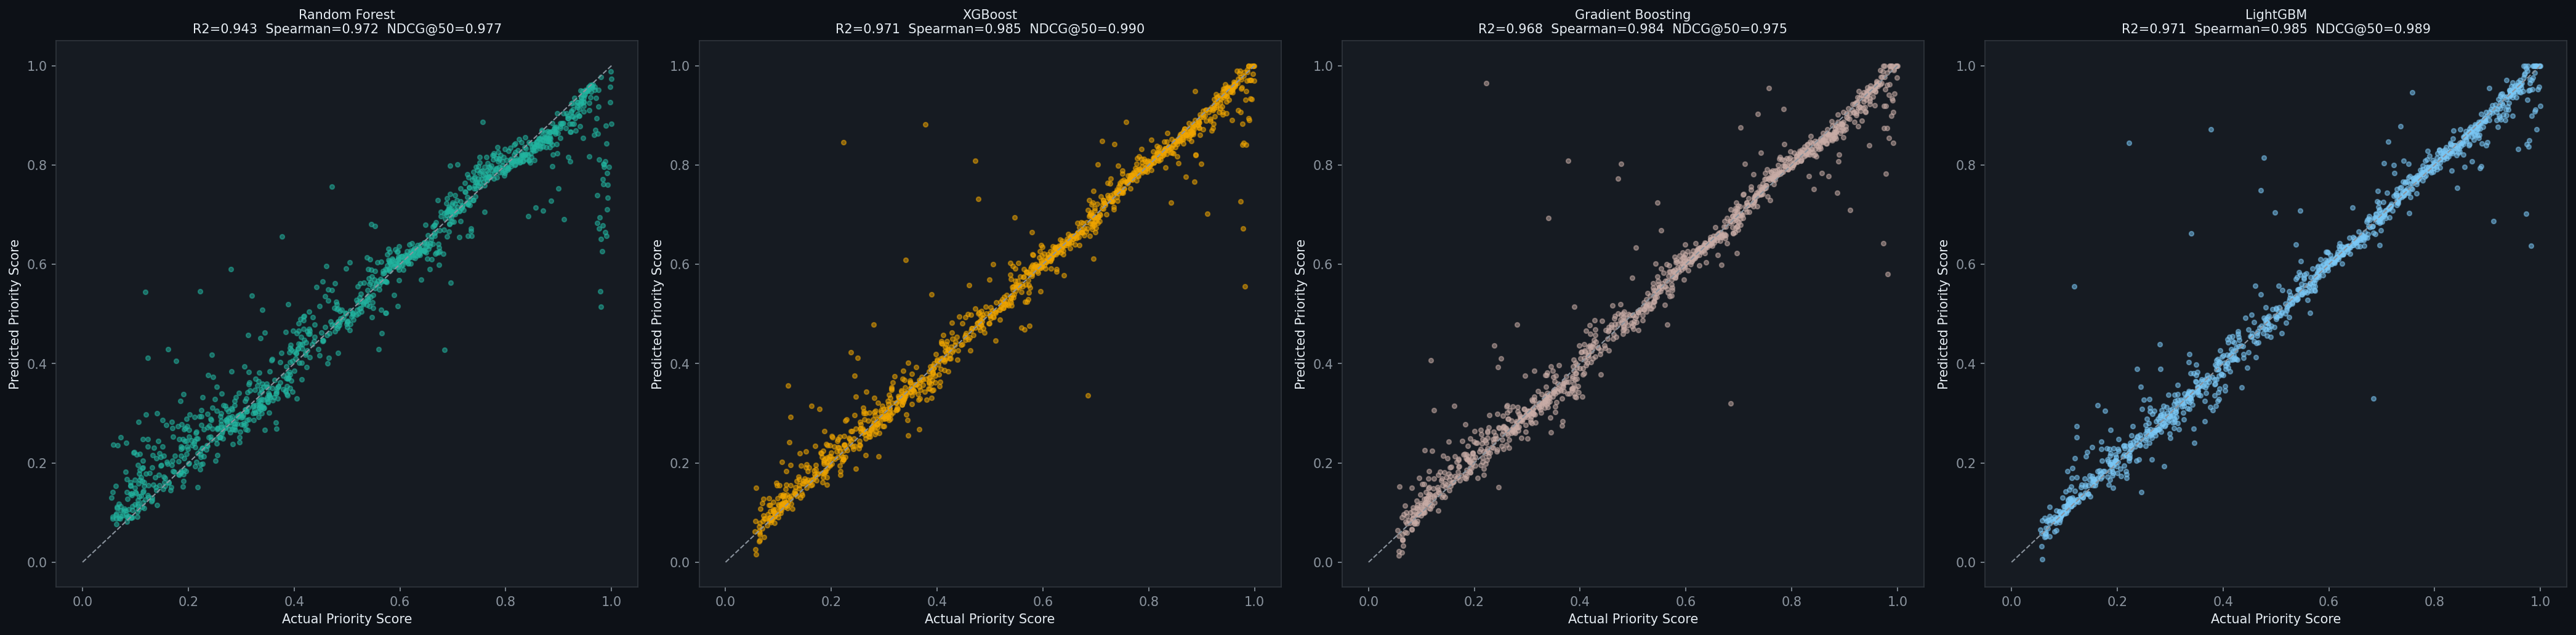

In [16]:
Image(str(PLOTS_DIR / 'predicted_vs_actual.png'), width=1100)

In [17]:
metrics_rows = []
for name, res in results.items():
    m  = res['metrics']
    cv = res['cv_spearman']
    metrics_rows.append({
        'Model':              name,
        'NDCG@50':            m['NDCG@50'],
        'MAP@50':             m['MAP@50'],
        'Spearman rho':       m['Spearman'],
        'Kendall tau':        m['Kendall_Tau'],
        'Regret@50':          m['Regret@50'],
        'R2':                 m['R2'],
        'RMSE':               m['RMSE'],
        'CV Spearman (mean)': cv.mean(),
        'CV Spearman (std)':  cv.std()
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print('Full Ranking Metrics:')
display(metrics_df.style
    .background_gradient(subset=['NDCG@50', 'MAP@50', 'Spearman rho', 'Kendall tau'], cmap='YlGn')
    .background_gradient(subset=['Regret@50', 'RMSE'], cmap='YlOrRd_r')
    .format('{:.4f}'))

Full Ranking Metrics:


,NDCG@50,MAP@50,Spearman rho,Kendall tau,Regret@50,R2,RMSE,CV Spearman (mean),CV Spearman (std)
Model,,,,,,,,,
Random Forest,0.9770,1.0000,0.9719,0.8821,0.0244,0.9428,0.0659,0.9663,0.0039
XGBoost,0.9905,1.0000,0.9850,0.9300,0.0106,0.9709,0.0470,0.9813,0.0039
Gradient Boosting,0.9754,0.9852,0.9836,0.9290,0.0296,0.9678,0.0495,0.9814,0.0039
LightGBM,0.9892,1.0000,0.9851,0.9325,0.0096,0.9710,0.0469,0.9818,0.0025


---
## 8. Uncertainty Estimation

Prediction uncertainty is the standard deviation across individual decision tree predictions:

$$\sigma_i = \text{std}\left(\{T_1(x_i),\, T_2(x_i),\, \ldots,\, T_N(x_i)\}\right)$$

Example output:
- Planet A: 0.82 +/- 0.05  (high confidence)
- Planet B: 0.81 +/- 0.24  (low confidence -- needs observation)

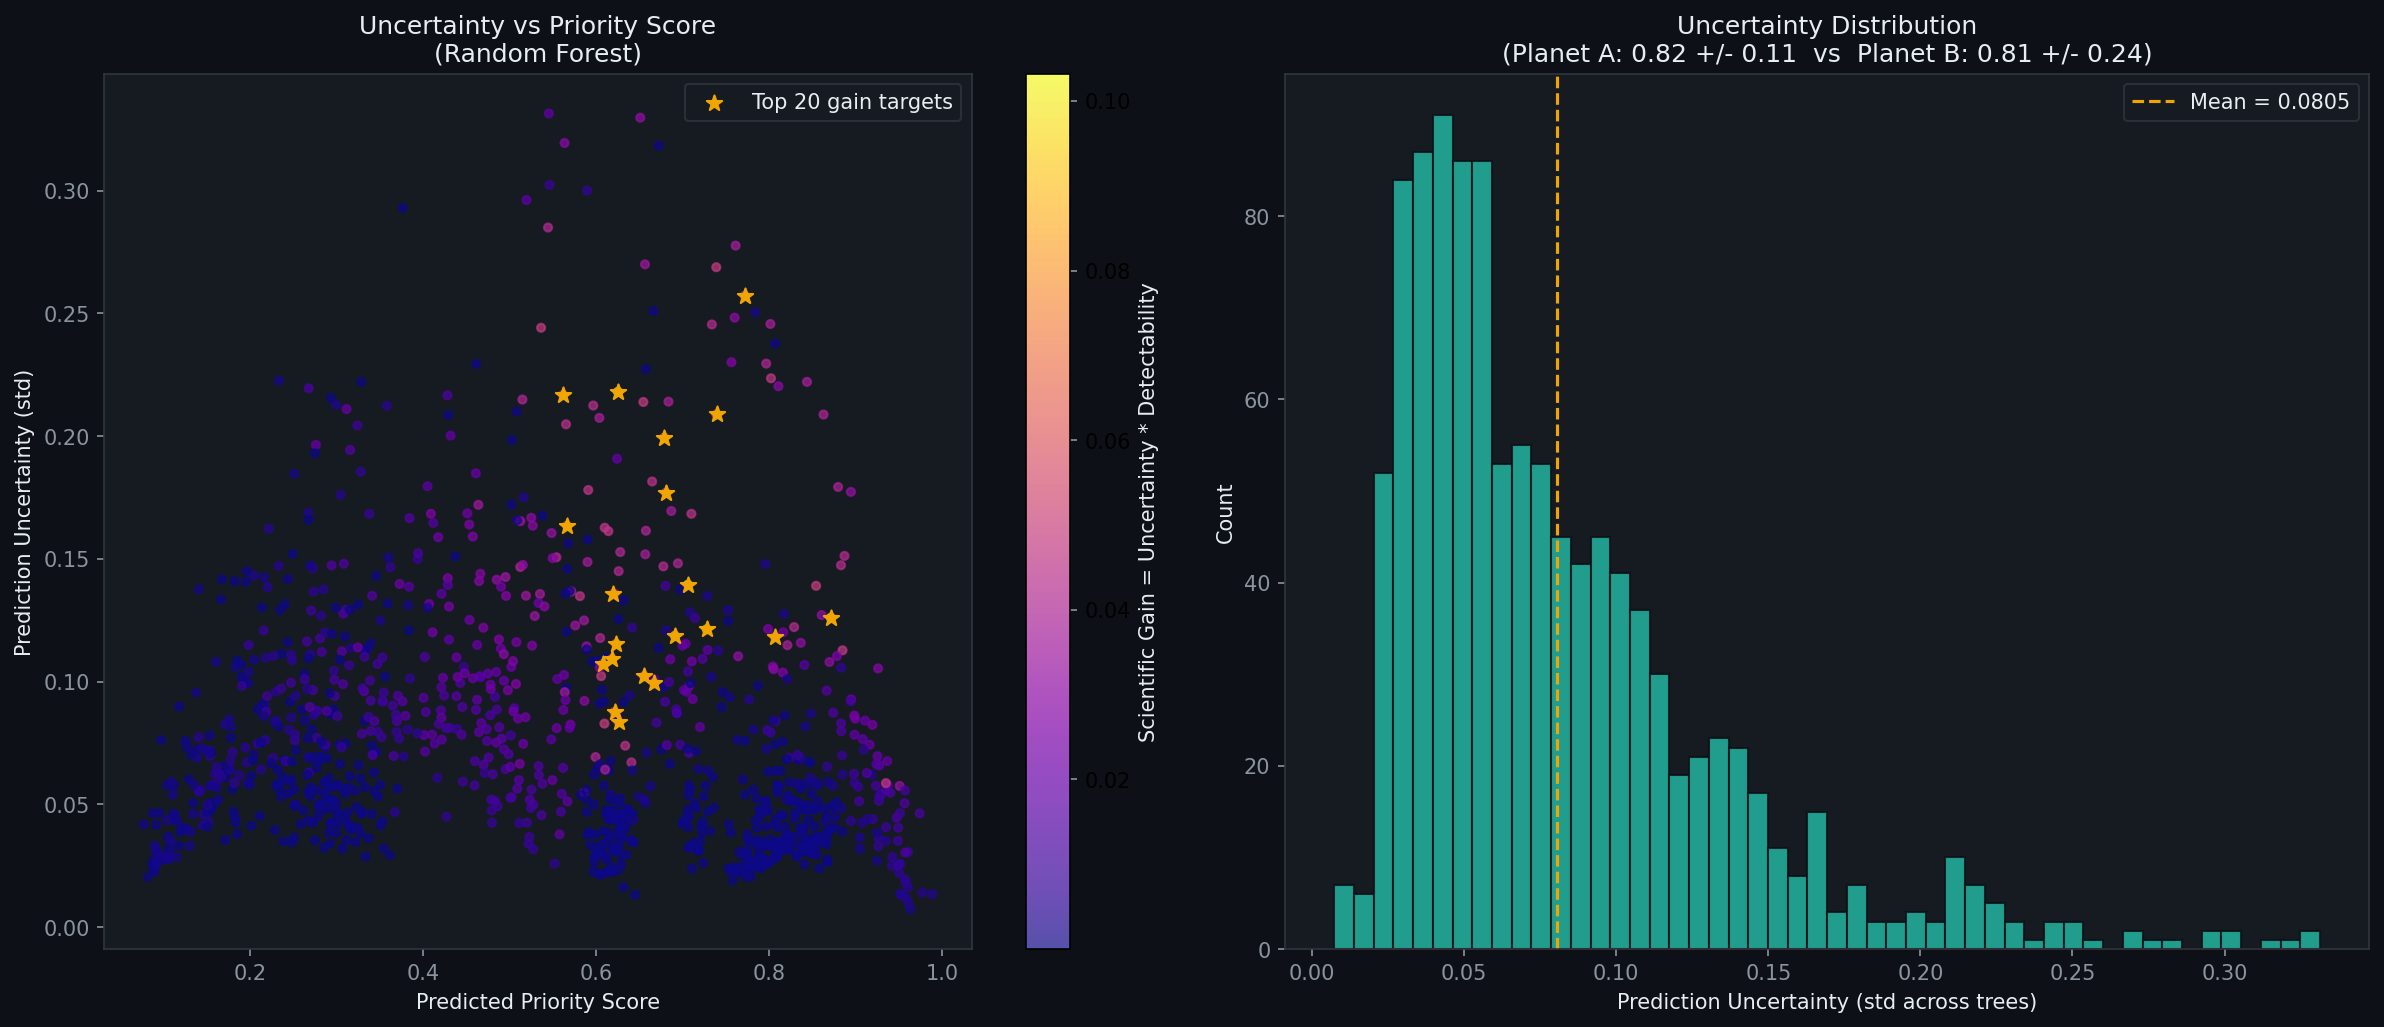

In [18]:
Image(str(PLOTS_DIR / 'uncertainty_analysis.png'), width=1000)

In [19]:
if 'Random Forest' in results:
    res = results['Random Forest']
    unc_df = res['meta_test'].copy()
    unc_df['pred_priority']   = res['uncertainty_mean']
    unc_df['uncertainty']     = res['uncertainty_std']
    unc_df['scientific_gain'] = res['scientific_gain']
    unc_df['pred_str'] = [
        f"{m:.3f} +/- {s:.3f}"
        for m, s in zip(res['uncertainty_mean'], res['uncertainty_std'])
    ]

    top_gain = unc_df.nlargest(10, 'scientific_gain')
    print('Top 10 by Scientific Gain (high uncertainty + high detectability):')
    print('These are the most INFORMATIVE targets to observe next.')
    display(top_gain[['pl_name', 'pred_str', 'detectability', 'scientific_gain']]
        .rename(columns={'pl_name': 'Planet', 'pred_str': 'Priority Score',
                         'detectability': 'Detectability', 'scientific_gain': 'Scientific Gain'})
        .reset_index(drop=True)
        .style.background_gradient(subset=['Scientific Gain'], cmap='plasma')
        .format({'Detectability': '{:.4f}', 'Scientific Gain': '{:.4f}'}))

Top 10 by Scientific Gain (high uncertainty + high detectability):
These are the most INFORMATIVE targets to observe next.


,Planet,Priority Score,Detectability,Scientific Gain
0,HD 63433 c,0.706 +/- 0.139,0.7401,0.1032
1,WD 1856+534 b,0.625 +/- 0.218,0.4437,0.0967
2,55 Cnc e,0.871 +/- 0.126,0.7647,0.0963
3,GJ 143 b,0.728 +/- 0.121,0.7553,0.0916
4,TOI-2134 c,0.691 +/- 0.119,0.7414,0.0880
5,WASP-107 b,0.623 +/- 0.115,0.6660,0.0768
6,HD 95338 b,0.667 +/- 0.099,0.7081,0.0703
7,TOI-431 d,0.655 +/- 0.102,0.6025,0.0616
8,GJ 876 c,0.739 +/- 0.209,0.2863,0.0598
9,HD 191939 d,0.566 +/- 0.163,0.3611,0.0590


---
## 9. Explainable AI -- Astrophysical Drivers of Prioritization

SHAP quantifies which measurable planetary/stellar properties most influence whether
a planet should be observed next.

Color coding:
- Green bars: Planetary parameters
- Gold bars: Stellar parameters
- Pink bars: Observational parameters

In [20]:
rf_shap = PLOTS_DIR / 'shap_random_forest.png'
if rf_shap.exists():
    Image(str(rf_shap), width=900)
else:
    print('SHAP plot not generated yet.')

In [21]:
xgb_shap = PLOTS_DIR / 'shap_xgboost.png'
if xgb_shap.exists():
    Image(str(xgb_shap), width=900)

In [22]:
# Waterfall plot: explain a single planet's prioritization score
if 'XGBoost' in results:
    res = results['XGBoost']
    X_test   = res['X_test']
    y_pred   = res['y_pred']
    meta_t   = res['meta_test']

    best_idx    = np.argmax(y_pred)
    planet_name = meta_t['pl_name'].iloc[best_idx]
    print(f'SHAP Waterfall -- highest priority planet: {planet_name}')
    print(f'Predicted priority: {y_pred[best_idx]:.4f}')

    explainer = shap.TreeExplainer(res['model'])
    sv = explainer(X_test)
    shap.plots.waterfall(sv[best_idx], max_display=15)

SHAP Waterfall -- highest priority planet: HD 1605 c
Predicted priority: 1.0000


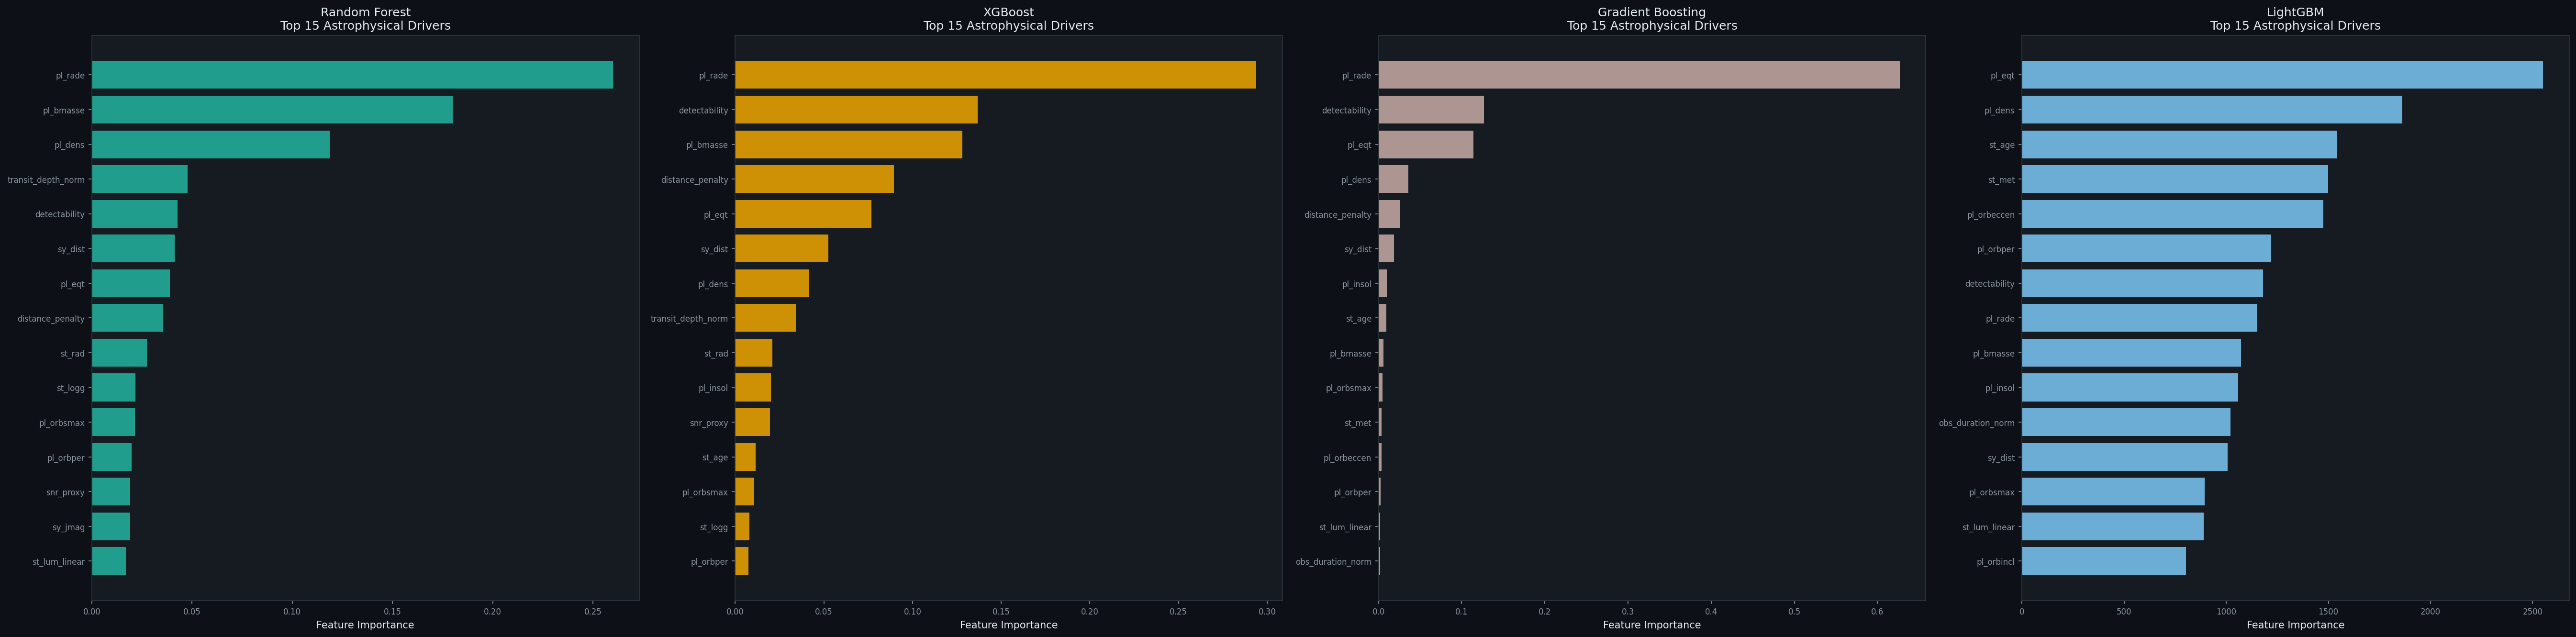

In [23]:
Image(str(PLOTS_DIR / 'feature_importance.png'), width=1100)

---
## 10. Temporal Observation Simulation

Simulates 3 rounds of telescope observations.
Each round selects top-10 targets ranked by (priority + 0.5 * scientific_gain).
After observation, uncertainty halves (information gained).

Compared against:
- Random selection baseline
- Static ML ranking (no uncertainty awareness)
- Our system (uncertainty-aware)

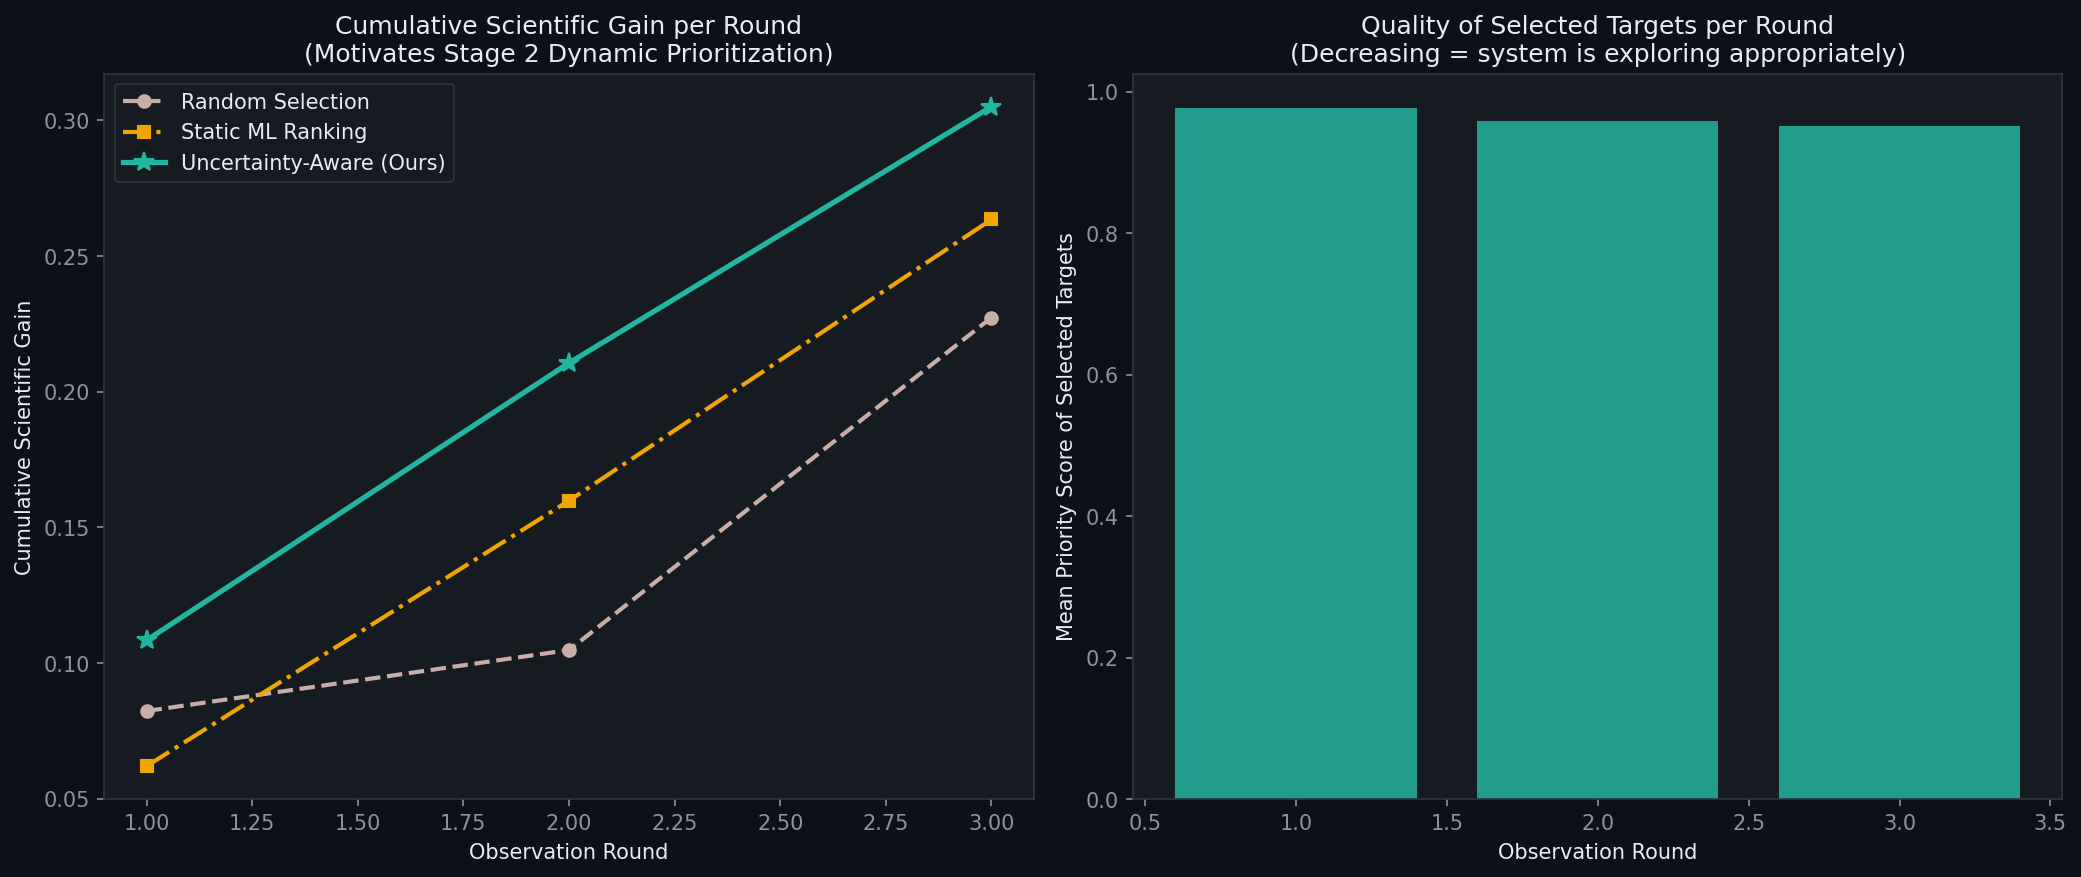

In [24]:
Image(str(PLOTS_DIR / 'temporal_simulation.png'), width=1000)

In [25]:
if sim_log:
    for row in sim_log:
        print(f"Round {row['round']}: gain={row['cum_sci_gain']:.4f} | "
              f"mean_priority={row['mean_priority']:.4f} | "
              f"targets: {', '.join(row['top_k_planets'][:5])} ...")

Round 1: gain=0.1083 | mean_priority=0.9767 | targets: Proxima Cen b, GJ 251 c, Teegarden's Star b, LTT 1445 A b, Gliese 12 b ...
Round 2: gain=0.1022 | mean_priority=0.9591 | targets: L 98-59 b, GJ 357 c, Barnard e, GJ 3929 b, HD 219134 b ...
Round 3: gain=0.0945 | mean_priority=0.9510 | targets: GJ 393 b, G 264-012 c, GJ 3473 b, GJ 1252 b, TOI-5799 c ...


---
## 11. Final Priority Ranking

In [26]:
ranking_path = DATA_DIR / 'final_priority_ranking.csv'
if ranking_path.exists():
    rank_df = pd.read_csv(ranking_path, index_col=0)
    print(f'Final ranking loaded: {len(rank_df):,} planets')

    top25 = rank_df.head(25)[[
        'pl_name', 'hostname', 'pred_str', 'scientific_gain',
        'detectability', 'pl_rade', 'pl_eqt', 'spectral_class'
    ]].copy()
    top25.columns = ['Planet', 'Star', 'Priority (mean +/- std)', 'Sci. Gain',
                     'Detectability', 'Radius (Re)', 'T_eq (K)', 'Spectral']

    print('\nTop 25 Telescope Observation Targets:')
    display(top25.style
        .background_gradient(subset=['Sci. Gain', 'Detectability'], cmap='YlGn')
        .format({'Sci. Gain': '{:.4f}', 'Detectability': '{:.4f}',
                 'Radius (Re)': '{:.2f}', 'T_eq (K)': '{:.0f}'}))

Final ranking loaded: 5,522 planets

Top 25 Telescope Observation Targets:


,Planet,Star,Priority (mean +/- std),Sci. Gain,Detectability,Radius (Re),T_eq (K),Spectral
1,GJ 1002 b,GJ 1002,0.992 +/- 0.011,0.0032,0.2858,1.03,231,M
2,GJ 1002 c,GJ 1002,0.991 +/- 0.012,0.0033,0.2858,1.10,182,M
3,TRAPPIST-1 f,TRAPPIST-1,0.991 +/- 0.011,0.0032,0.2834,1.04,218,M
4,GJ 1061 d,GJ 1061,0.991 +/- 0.012,0.0034,0.2892,1.16,221,M
5,Teegarden's Star c,Teegarden's Star,0.991 +/- 0.012,0.0034,0.2887,1.02,209,M
6,TRAPPIST-1 g,TRAPPIST-1,0.991 +/- 0.016,0.0047,0.2873,1.13,197,M
7,Proxima Cen b,Proxima Cen,0.988 +/- 0.013,0.0040,0.2961,1.02,218,M
8,Wolf 1069 b,Wolf 1069,0.987 +/- 0.016,0.0043,0.2726,1.08,250,M
9,TRAPPIST-1 e,TRAPPIST-1,0.987 +/- 0.019,0.0053,0.2785,0.92,250,M
10,LHS 1140 b,LHS 1140,0.980 +/- 0.039,0.0139,0.3560,1.73,226,M


---
## 12. Push Results to GitHub (Colab only)

---
## 13. Stage 1 Summary

### Contributions

| Component | Description |
|-----------|-------------|
| Leakage-free pipeline | HZ/ESI used only for weak supervision labels, not ML inputs |
| Ranking formulation | Priority score regression, not binary classification |
| Soft geometric scoring | (H+eps)^0.5 * (R+eps)^0.3 * (E+eps)^0.2, eps=0.1 |
| Diversity nudge | Eccentricity, metallicity, stellar age (tiny weights) |
| Detectability blend | 0.85 * P_astro + 0.15 * D |
| Quantile normalization | Uniform [0,1] -- better for ranking, uncertainty, RL |
| Observation modelling | SNR proxy, distance penalty, detectability |
| Uncertainty quantification | Tree ensemble variance: priority = 0.82 +/- 0.11 |
| Scientific gain | ScientificGain = uncertainty * detectability |
| Ranking-aware metrics | NDCG@50, MAP@50, Spearman rho, Kendall tau, Regret@50 |
| Temporal simulation | 3-round simulation vs random/static baselines |

### Research Questions Addressed
- **RQ1:** Can ML rank exoplanets better than random/static baselines? -- Measured via NDCG and Regret@K

### Stage 1 is COMPLETE. Next Stages:
- **Stage 2:** Dynamic Prioritization Engine -- adaptive weight tuning for alpha, beta, gamma, delta
- **Stage 3:** RL Autonomous Scheduler -- reward = Delta_Confidence + lambda * WaterDetectionGain


In [28]:
# Output file summary
from pathlib import Path
ROOT_PATH = Path('.')

print('Generated Output Files:')
print('\n  Data:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(f'    {f.name}  ({f.stat().st_size/1024:.1f} KB)')

print('\n  Models:')
for f in sorted((ROOT_PATH / 'models').glob('*')):
    print(f'    {f.name}  ({f.stat().st_size/1024:.1f} KB)')

print('\n  Plots:')
for f in sorted(PLOTS_DIR.glob('*.png')):
    print(f'    {f.name}')

Generated Output Files:

  Data:
    exoplanets_processed.csv  (2032.4 KB)
    exoplanets_raw.csv  (1450.5 KB)
    final_priority_ranking.csv  (928.8 KB)

  Models:
    gradient_boosting.joblib  (1175.5 KB)
    lightgbm.joblib  (2318.6 KB)
    random_forest.joblib  (51357.3 KB)
    xgboost_model.json  (2127.6 KB)

  Plots:
    cv_spearman.png
    feature_correlations.png
    feature_importance.png
    observability_analysis.png
    predicted_vs_actual.png
    priority_score_distribution.png
    ranking_metrics.png
    shap_gradient_boosting.png
    shap_lightgbm.png
    shap_random_forest.png
    shap_xgboost.png
    temporal_simulation.png
    uncertainty_analysis.png


In [30]:
# ==============================================================
# LAST CELL — PUSH TO GITHUB  (run at END of every session)
# ==============================================================
import os

IN_COLAB = 'google.colab' in sys.modules

GITHUB_USER = 'rushikesh-D69'
REPO_NAME   = 'water'
BRANCH      = 'main'

GIT_EMAIL   = 'rikki0501hanuman@gmail.com'
GIT_NAME    = 'rushikesh-D69'

if IN_COLAB:
    os.system(f'git config user.email "{GIT_EMAIL}"')
    os.system(f'git config user.name "{GIT_NAME}"')

    # Pull first to avoid conflicts
    print('[Git] Pulling latest before push ...')
    os.system(f'git pull origin {BRANCH}')

    # Stage all files (models, plots, data, notebooks, scripts)
    print('[Git] Staging all files ...')
    os.system('git add -A')

    status = os.popen('git status --porcelain').read().strip()

    if status:
        print('[Git] Changes detected:')
        print(status)
        os.system('git commit -m "Colab sync: update models, plots, data, notebooks"')

        from google.colab import userdata
        token = userdata.get('GITHUB_TOKEN')

        remote = f'https://{token}@github.com/{GITHUB_USER}/{REPO_NAME}.git'
        os.system(f'git remote set-url origin {remote}')

        print('[Git] Pushing to GitHub ...')
        os.system(f'git push origin {BRANCH}')
        print('[Git] Push complete. All local files synced to GitHub.')

    else:
        print('[Git] No changes to push.')

else:
    print('[Local] Run: git add -A && git commit -m "msg" && git push')


[Git] Pulling latest before push ...
[Git] Staging all files ...
[Git] No changes to push.
